# SurveilAMR — Exploratory Data Analysis

**Surveillance Intelligence for Antimicrobial Resistance Trends**
**2026 Vivli AMR Surveillance Data Challenge · Data Request ID 00013370**

This notebook is the primary analytical narrative for the SurveilAMR project. It explores
all **five** Vivli-approved datasets end to end:

| # | Dataset | Contributor | Isolates / Patients | Scope |
|---|---------|-------------|----------------------|-------|
| 1 | **ATLAS_Antibiotics** | Pfizer Inc. | 1,011,168 isolates | 83 countries, 400 species, 2004-2024 |
| 2 | **KEYSTONE** (Omadacycline) | Paratek Pharmaceuticals | 96,302 isolates | 20 countries, 2015-2025 |
| 3 | **Bedaquiline DREAM** | Johnson & Johnson | 5,928 MDR-TB isolates | 11 countries, 2011-2019 |
| 4 | **GASAR (Study III)** | Venus Remedies | 496 isolates | India, 2022-2023 |
| 5 | **SPIDAAR RWE Study** | Pfizer Inc. | 244 isolates / 336 patients | Ghana, Kenya, Malawi, Uganda |

**Repository:** https://github.com/Nana-Safo-Duker/2026-Vivli-AMR-Data-Challenge-SurveilAMR

**Data Request DOI:** https://doi.org/10.25934/PR00013370

> **Reproducibility note.** Raw Vivli data cannot be redistributed (Data Use Agreement).
> This notebook reads the *processed* summary tables in `data/processed/`, which are
> generated from the raw files by `scripts/run_analysis.py`, `scripts/analyze_supplementary.py`,
> and `scripts/analyze_spidaar.py` (or `scripts/run_all.py` to run everything at once).
> If you have obtained approved raw access, place the raw files in `data/raw/` and re-run
> those scripts before executing this notebook to refresh every number and figure below.

## Contents

1. Setup
2. ATLAS_Antibiotics — global bacterial surveillance
3. KEYSTONE — omadacycline surveillance
4. Bedaquiline DREAM — MDR/XDR-TB surveillance
5. GASAR Study III — Gram-negative resistance mechanisms (India)
6. SPIDAAR RWE Study — sub-Saharan Africa isolate & patient data
7. Cross-dataset synthesis and stewardship implications
8. Limitations
9. References

## 1. Setup

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

ROOT = Path("..").resolve()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "outputs" / "figures"

def show_figure(name, width=11):
    """Render a pre-generated pipeline figure inline for reference."""
    img = mpimg.imread(FIG / name)
    fig, ax = plt.subplots(figsize=(width, width * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    ax.axis("off")
    plt.show()

print("Processed data available:", sorted(p.name for p in PROC.glob("*")))

Processed data available: ['dataset_summary.json', 'dream_bdq_by_continent.csv', 'dream_bdq_by_year.csv', 'gasar_gene_counts.csv', 'gasar_phenotype_counts.csv', 'keystone_omadacycline_by_year.csv', 'keystone_omadacycline_mic.csv', 'spidaar_amr_flags.csv', 'spidaar_isolate_groups_by_country.csv', 'spidaar_los_by_outcome.csv', 'spidaar_patient_demographics.csv', 'spidaar_severity_by_outcome.csv', 'spidaar_summary.json', 'supplementary_datasets_summary.json', 'surveilamr_resistance_by_country.csv', 'surveilamr_resistance_by_year.csv']


## 2. ATLAS_Antibiotics

Pfizer's **ATLAS_Antibiotics** extract is the backbone of SurveilAMR: **1,011,168 isolates**
collected between **2004 and 2024** across **83 countries** and **400 species**, with
susceptibility results for up to 65 antibiotics and 17 beta-lactamase gene markers per isolate.
Because the raw extract is ~387 MB, `scripts/run_analysis.py` streams it in 100,000-row chunks
rather than loading it fully into memory — the same approach used in production surveillance
pipelines that must scale beyond a single workstation's RAM.

### 2.1 Cohort overview

In [ ]:
with open(PROC / "dataset_summary.json", encoding="utf-8") as f:
    atlas = json.load(f)

print(f"Total isolates      : {atlas['total_rows']:,}")
print(f"Countries           : {atlas['n_countries']}")
print(f"Species             : {atlas['n_species']}")
print(f"Year range          : {atlas['year_range'][0]}-{atlas['year_range'][1]}")
print(f"African isolates    : {atlas['africa_rows']:,} across {len(atlas['africa_countries_present'])} countries")
print(f"Contributing studies: {atlas['studies']}")

pd.Series(atlas["top_species"], name="Isolates").to_frame().head(10)

Total isolates      : 1,011,168
Countries           : 83
Species             : 400
Year range          : 2004-2024
African isolates    : 29,387 across 12 countries
Contributing studies: {'TEST': 413245, 'Inform': 219885, 'ATLAS': 378038}


,Isolates
Staphylococcus aureus,172883
Escherichia coli,125878
Pseudomonas aeruginosa,115807
Klebsiella pneumoniae,106946
Streptococcus pneumoniae,49165
Enterobacter cloacae,46383
Acinetobacter baumannii,45011
Enterococcus faecalis,40136
Haemophilus influenzae,33669
Serratia marcescens,27240


*Staphylococcus aureus* (172,883), *Escherichia coli* (125,878), *Pseudomonas aeruginosa*
(115,807), and *Klebsiella pneumoniae* (106,946) are the four most frequently isolated
organisms — together they make up over half of the entire ATLAS cohort and anchor the
ESKAPE-pathogen resistance analysis below.

### 2.2 Species and country distribution

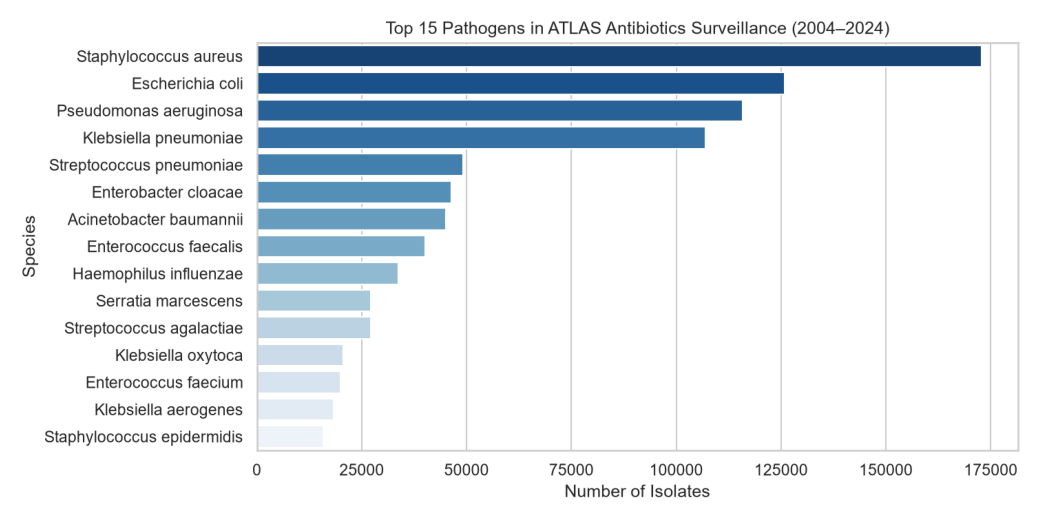

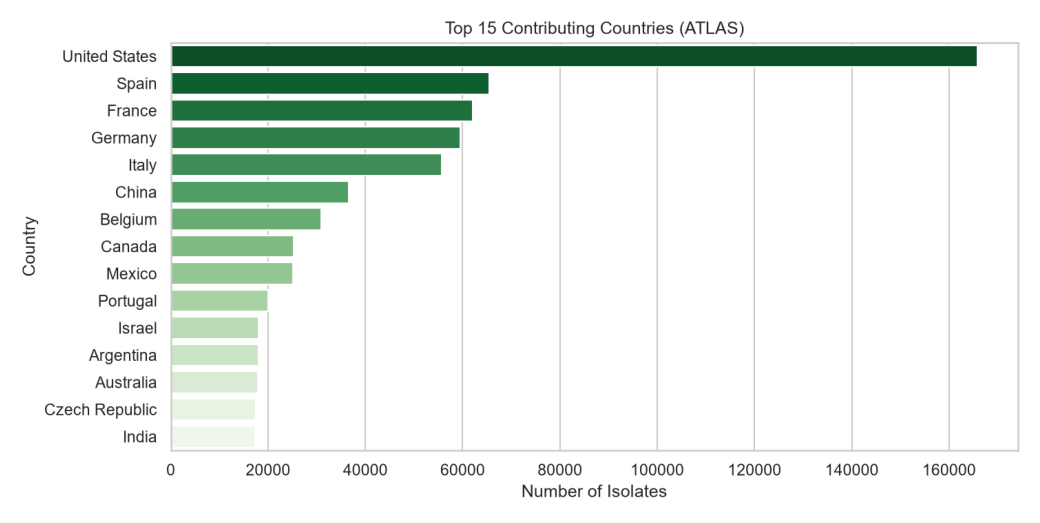

In [ ]:
show_figure("fig1_species_distribution.png")
show_figure("fig2_country_distribution.png")

The United States (165,880), Spain (65,418), France (62,065), and Germany (59,538) contribute
the most isolates overall. Coverage of low- and middle-income countries is comparatively
sparse — Africa contributes only 29,387 isolates (2.9% of ATLAS) across 12 countries, which
is one of the central equity gaps SurveilAMR aims to highlight for LMIC stewardship programs.

### 2.3 Temporal resistance trends — ESKAPE pathogens

For each priority pathogen we track resistance to its most clinically relevant primary
antibiotic (e.g. meropenem for the Gram-negative ESKAPE members, oxacillin/methicillin for
*S. aureus*, vancomycin for *E. faecalis*), restricting to species/antibiotic/year cells with
at least 30 tested isolates to avoid unstable small-sample estimates.

Klebsiella pneumoniae     Meropenem    2004:   9.9%  ->  2024:  20.7%
Escherichia coli          Meropenem    2005:   0.0%  ->  2024:   3.2%
Acinetobacter baumannii   Meropenem    2005:  59.5%  ->  2024:  68.5%
Staphylococcus aureus     Oxacillin    2012:  59.5%  ->  2024:  25.7%


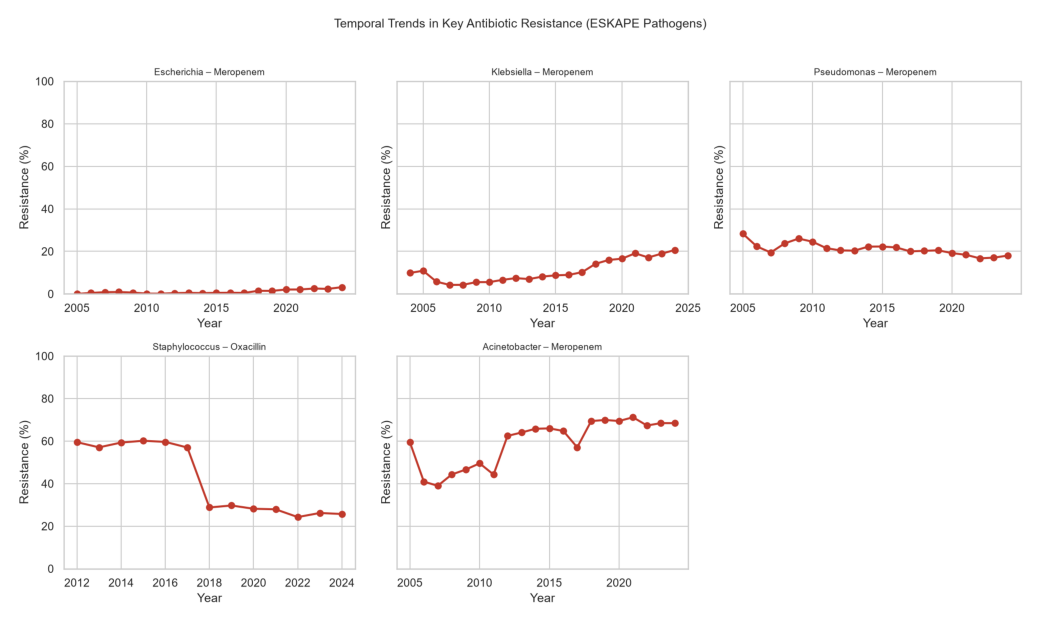

In [ ]:
yearly = pd.read_csv(PROC / "surveilamr_resistance_by_year.csv")

focus_pairs = [
    ("Klebsiella pneumoniae", "Meropenem"),
    ("Escherichia coli", "Meropenem"),
    ("Acinetobacter baumannii", "Meropenem"),
    ("Staphylococcus aureus", "Oxacillin"),
]
for species, abx in focus_pairs:
    sub = yearly[(yearly["Species"] == species) & (yearly["Antibiotic"] == abx)].sort_values("Year")
    first, last = sub.iloc[0], sub.iloc[-1]
    print(f"{species:<25} {abx:<12} {first['Year']}: {first['Resistance_Pct']:>5.1f}%  ->  {last['Year']}: {last['Resistance_Pct']:>5.1f}%")

show_figure("fig3_resistance_trends.png")

**Key temporal signal:** *K. pneumoniae* meropenem resistance rose roughly five-fold, from
4.2% in 2007 to 20.7% in 2024 — a textbook early-warning trend for carbapenem-sparing
empiric protocols. *A. baumannii* meropenem resistance climbed from ~39% (2006) to a
plateau near 68-71% since 2018, reflecting how quickly this pathogen exhausted carbapenem
options in ICU settings. *S. aureus* oxacillin (MRSA proxy) resistance nearly halved after
2017 (60% -> 26%), consistent with broader global MRSA decline trends reported elsewhere,
while *E. coli* meropenem resistance — although still low in absolute terms — more than
doubled since 2018 (1.5% -> 3.2%), an early carbapenem-resistance signal worth monitoring
given *E. coli*'s community-acquired reservoir.

### 2.4 Country-level resistance and beta-lactamase gene prevalence

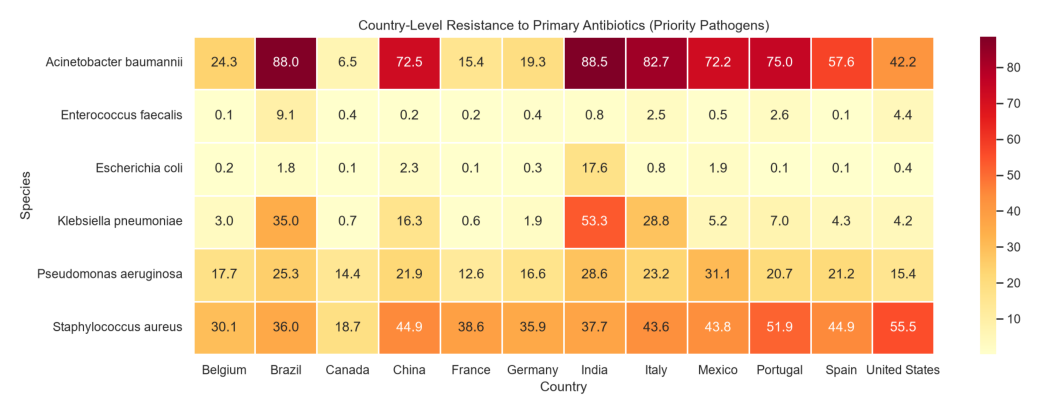

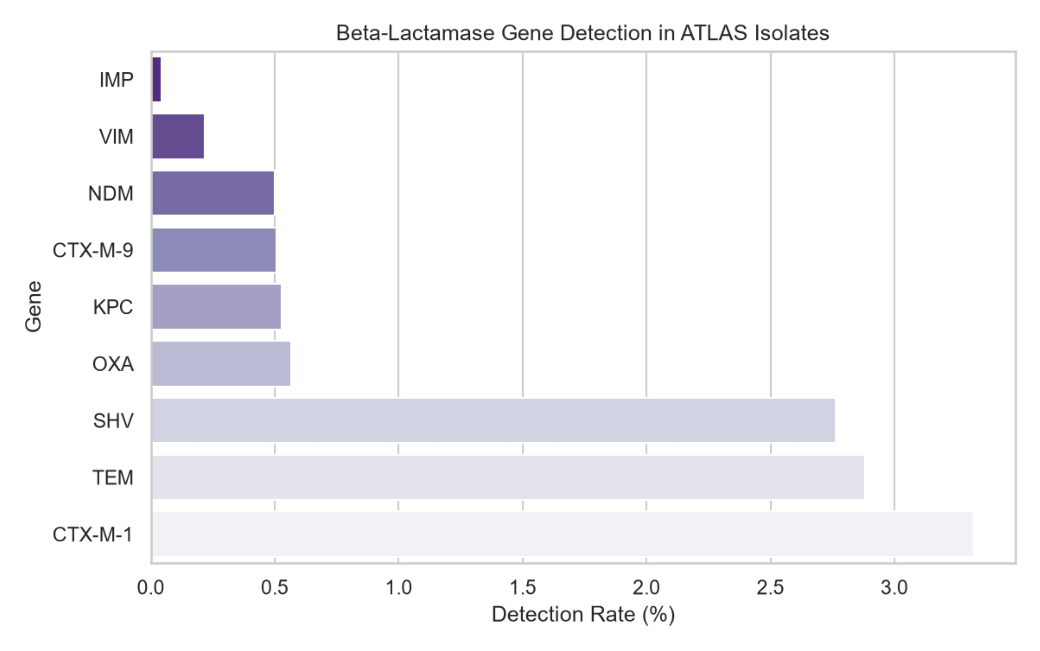

,Detection_Pct
CTX-M-1,3.3221
TEM,2.8804
SHV,2.7629
OXA,0.5647
KPC,0.5268
CTX-M-9,0.5068
NDM,0.4986
VIM,0.2188
IMP,0.0422


In [ ]:
show_figure("fig4_country_resistance_heatmap.png")
show_figure("fig5_gene_prevalence.png")

genes = pd.Series(atlas["gene_detection_pct"], name="Detection_Pct").sort_values(ascending=False)
genes.to_frame()

India (17.6% *E. coli* meropenem-R, 53.3% *K. pneumoniae* meropenem-R) and several
Eastern European / Middle Eastern countries (Ukraine, Greece, Croatia, Latvia, Jordan) show
the highest resistance burdens for carbapenems in Gram-negatives, while *A. baumannii*
meropenem resistance exceeds 90% in Ukraine, Latvia, Croatia, Jordan, and Greece. CTX-M-1
(3.32%) is the most frequently detected beta-lactamase gene marker in ATLAS, followed by
TEM (2.88%) and SHV (2.76%) — consistent with globally dominant ESBL epidemiology — while
carbapenemase genes (KPC, NDM, VIM, IMP) remain individually rare (<0.6% each) but are
clinically significant given their association with the high-mortality phenotypes seen in
GASAR and SPIDAAR below.

### 2.5 Multidrug resistance proxy and the Africa gap

We define a simple **MDR proxy**: an isolate is flagged if it is resistant to \u2265 2 of its
species' 2-3 tracked antibiotic classes. This is a coarse approximation (true MDR
classification requires the full antibiogram) but is useful for rapid stewardship triage.

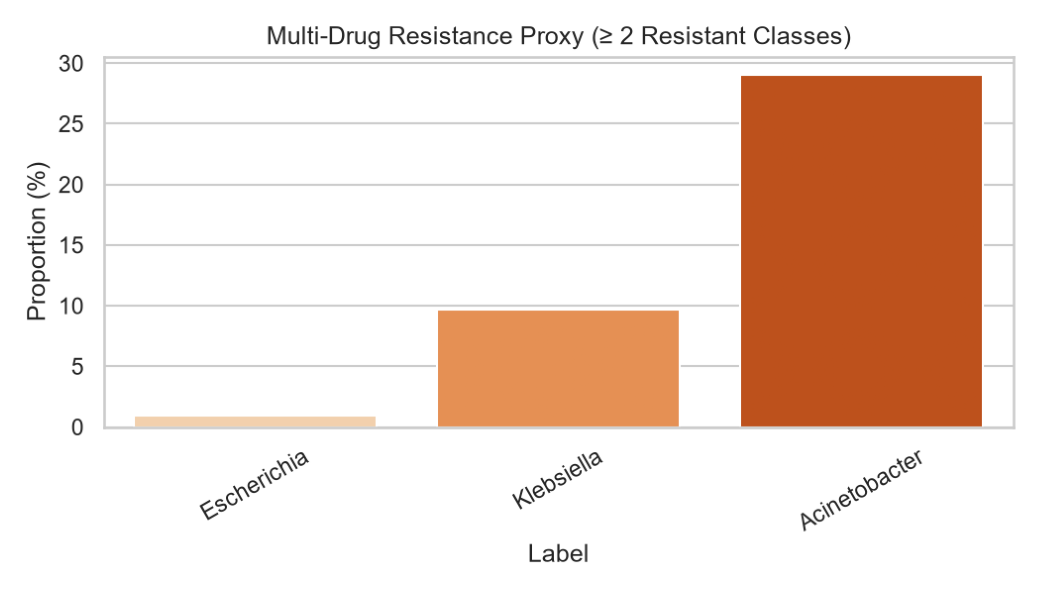

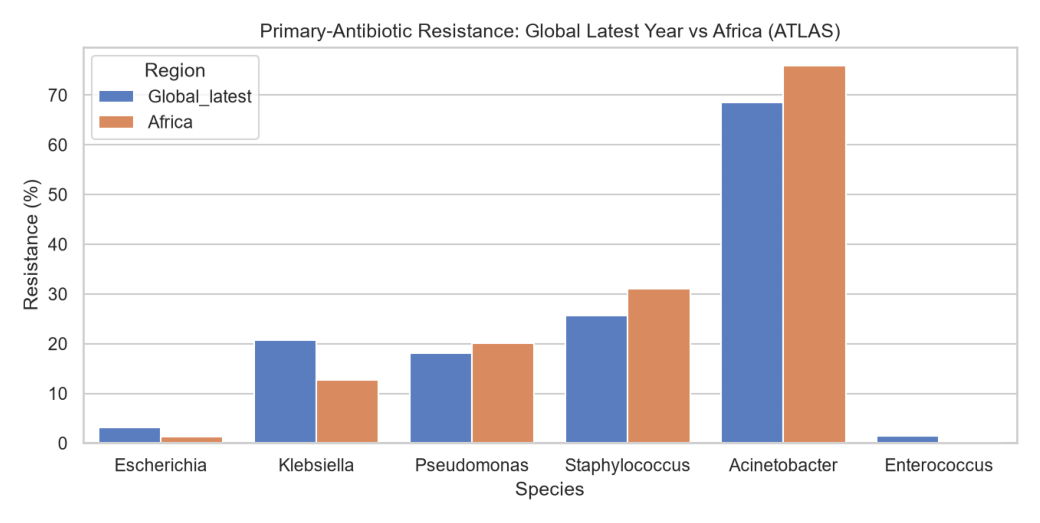

,Species,Antibiotic,Global_latest_pct,Africa_pct,Africa_n
0,Escherichia coli,Meropenem,3.18,1.36,4469
1,Klebsiella pneumoniae,Meropenem,20.67,12.78,4131
2,Pseudomonas aeruginosa,Meropenem,18.03,20.13,3547
3,Staphylococcus aureus,Oxacillin,25.73,31.01,3657
4,Acinetobacter baumannii,Meropenem,68.45,75.87,1496
5,Enterococcus faecalis,Vancomycin,1.45,0.09,1150


In [ ]:
show_figure("fig6_mdr_proxy.png")
show_figure("fig10_africa_vs_global.png")

africa_gap = []
for species, entry in atlas["resistance_trends"].items():
    years = entry.get("yearly_resistance_pct", {})
    if not years or "africa_resistance_pct" not in entry:
        continue
    latest_year = max(int(y) for y in years)
    africa_gap.append({
        "Species": species,
        "Antibiotic": entry["antibiotic"],
        "Global_latest_pct": years[str(latest_year)],
        "Africa_pct": entry["africa_resistance_pct"],
        "Africa_n": entry["africa_n"],
    })
pd.DataFrame(africa_gap)

*A. baumannii* shows both the highest global MDR proxy (29.1%) and the largest Africa
penalty: **75.9% meropenem resistance in Africa** vs. 68.5% globally in the latest year —
a 7-point excess burden concentrated in a pathogen with very few remaining oral or
affordable IV options in resource-limited ICUs. *K. pneumoniae* shows the opposite pattern
locally (12.8% Africa vs. 20.7% global-latest), suggesting either lower carbapenem selection
pressure or under-detection in African labs — both are actionable hypotheses for local AMR
surveillance capacity-building.

## 3. KEYSTONE

Paratek's **KEYSTONE** surveillance program tracks omadacycline (a novel aminomethylcycline)
and 30+ comparator agents. It is the largest supplementary dataset: **96,302 isolates**,
**165 species**, **20 countries**, 2015-2025 — though geographically concentrated in North
America (71,802, mostly USA) and Europe (24,500), with **no African sites**, a coverage gap
worth flagging for a novel-agent stewardship program targeting LMICs.

In [ ]:
with open(PROC / "supplementary_datasets_summary.json", encoding="utf-8") as f:
    supp = json.load(f)
keystone = supp["keystone"]

print(f"KEYSTONE n           : {keystone['n']:,}")
print(f"Years                : {keystone['years'][0]}-{keystone['years'][1]}")
print(f"Species / Countries  : {keystone['n_species']} / {keystone['n_countries']}")
print(f"Overall Oma MIC50    : {keystone['omadacycline_mic_overall_median']} \u00b5g/mL")
print(f"African isolates     : {keystone['africa_n']}")

mic_df = pd.DataFrame(keystone["mic_summary"]).sort_values("MIC90")
mic_df

KEYSTONE n           : 96,302
Years                : 2015-2025
Species / Countries  : 165 / 20
Overall Oma MIC50    : 0.5 µg/mL
African isolates     : 0


,Organism,n,MIC50,MIC90,mean
3,Streptococcus pneumoniae,6360,0.06,0.12,0.0630
0,Staphylococcus aureus,22121,0.12,0.25,0.1400
4,Enterococcus faecalis,3612,0.06,0.25,0.1074
1,Escherichia coli,15343,0.50,2.00,0.9186
2,Klebsiella pneumoniae,7804,2.00,4.00,2.7968
5,Pseudomonas aeruginosa,7837,32.00,32.00,26.6585


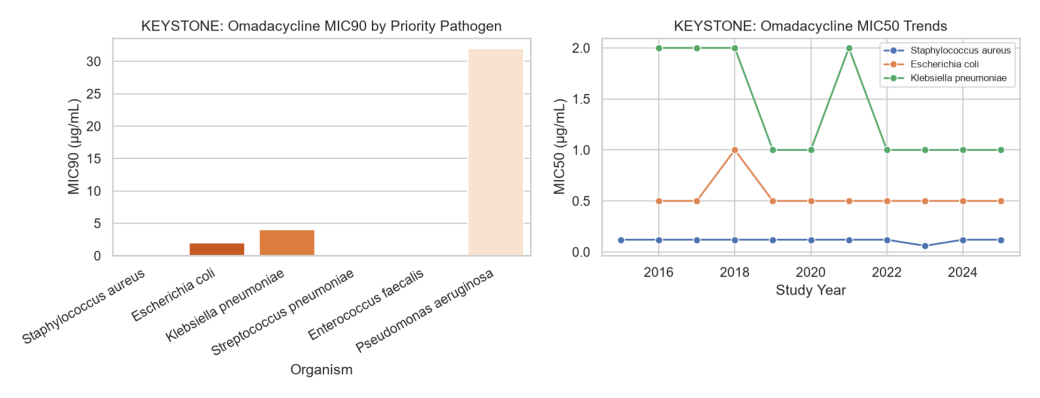

In [ ]:
show_figure("fig9_keystone_omadacycline.png")

Omadacycline retains strong in-vitro potency against Gram-positive priority pathogens —
MIC90 = 0.25 \u00b5g/mL for *S. aureus*, 0.25 \u00b5g/mL for *E. faecalis*, 0.12 \u00b5g/mL for
*S. pneumoniae* — with MIC50/MIC90 trends flat across 2015-2025 (no evidence of emerging
resistance). As expected for a tetracycline-class agent, it has no useful activity against
*P. aeruginosa* (MIC90 = 32 \u00b5g/mL), consistent with its approved indications
(community-acquired pneumonia and skin/soft-tissue infection, not intrinsically-resistant
non-fermenters).

## 4. Bedaquiline DREAM

Johnson & Johnson's **DREAM** ("Drug Resistance Evaluation of Antitubercular Medicines")
dataset provides bedaquiline (BDQ) and companion-drug MICs for **5,928 MDR/XDR-TB isolates**
across **11 countries** (2011-2019), with 978 African isolates (South Africa) and dense
coverage of the Rv0678, atpE, pepQ, and Rv1979c resistance-associated loci.

In [ ]:
dream = supp["dream"]
print(f"DREAM n              : {dream['n']:,}")
print(f"Years                : {dream['years'][0]}-{dream['years'][1]}")
print(f"Countries            : {dream['n_countries']}")
print(f"Median BDQ MIC       : {dream['bdq_mic_median']} \u00b5g/mL (mean {dream['bdq_mic_mean']})")
print(f"BDQ MIC > 0.25 \u00b5g/mL: {dream['bdq_gt_0_25_pct']}% of isolates")
print(f"African isolates     : {dream['africa_n']}")

print("\nTB subtype distribution (normalized from 40+ free-text spellings):")
pd.Series(dream["subtype_normalized"]).sort_values(ascending=False).to_frame("Count")

DREAM n              : 5,928
Years                : 2011-2019
Countries            : 11
Median BDQ MIC       : 0.03 µg/mL (mean 0.0535)
BDQ MIC > 0.25 µg/mL: 0.56% of isolates
African isolates     : 978

TB subtype distribution (normalized from 40+ free-text spellings):


,Count
MDR,4114
Pre-XDR,909
XDR,529
RR/RIF-resistant,280
Other/Unclassified,96


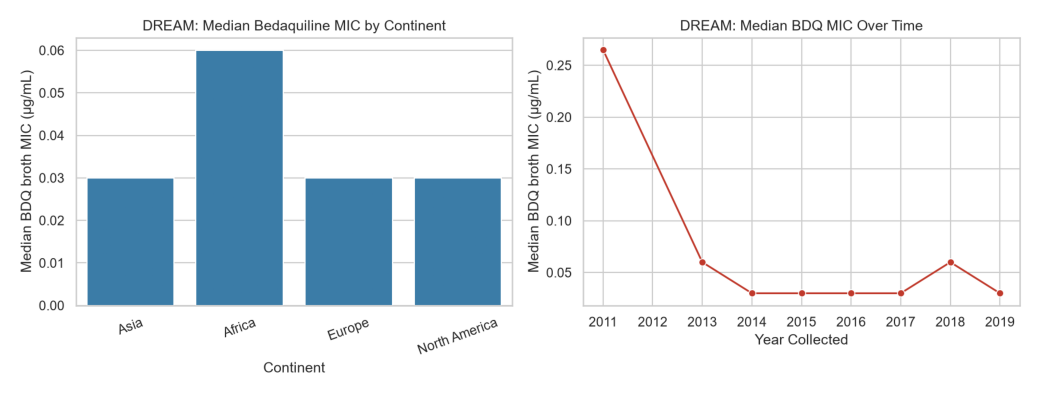

In [ ]:
show_figure("fig7_dream_bdq.png")

Bedaquiline MICs remain very low overall (median 0.03 \u00b5g/mL; only 0.56% of isolates
exceed the 0.25 \u00b5g/mL provisional resistance threshold), reassuring given the drug's
critical role for MDR/XDR-TB regimens. Africa shows a slightly elevated median (0.06 vs.
0.03 \u00b5g/mL elsewhere) — not resistance per se, but worth monitoring longitudinally as
bedaquiline use scales up under WHO's all-oral MDR-TB regimens (BPaLM). MDR (4,114
isolates) is the dominant subtype, with pre-XDR (909) and XDR (529) making up the more
severe tail of the cohort.

## 5. GASAR Study III

Venus Remedies' **GASAR (Study III)** dataset characterizes Gram-negative resistance
mechanisms and polymyxin B MICs for **496 isolates** from India (2022-2023), dominated by
*E. coli* (283) and *K. pneumoniae* (101).

In [ ]:
gasar = supp["gasar"]
print(f"GASAR n                    : {gasar['n']}")
print(f"Years                      : {gasar['years'][0]}-{gasar['years'][1]}")
print(f"Polymyxin B MIC median     : {gasar['poly_mic_median']} \u00b5g/mL")
print(f"Polymyxin B MIC >= 4 \u00b5g/mL: {gasar['poly_mic_ge4_pct']}% (reduced susceptibility)")
print(f"MBL / carbapenemase-positive phenotype: {gasar['mbl_or_carb_pct']}%")

print("\nTop gene combinations detected:")
pd.Series(gasar["gene_top"]).to_frame("Count")

GASAR n                    : 496
Years                      : 2022-2023
Polymyxin B MIC median     : 0.25 µg/mL
Polymyxin B MIC >= 4 µg/mL: 3.02% (reduced susceptibility)
MBL / carbapenemase-positive phenotype: 31.45%

Top gene combinations detected:


,Count
-,200
"VIM-1, NDM-1",41
TEM-1,21
NDM-1,18
"TEM-1, SHV-18",18
"TEM-1, CTX-M",16
"TEM-1, SHV-18, CTX-M",14
SHV-18,12
"SHV-18, CTX-M",11
VIM-1,11


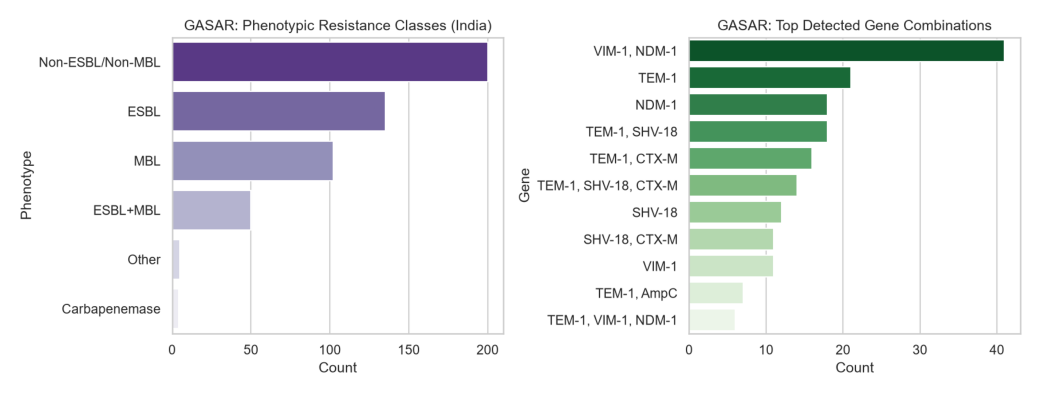

In [ ]:
show_figure("fig8_gasar_mechanisms.png")

Nearly a third of GASAR isolates (31.5%) carry an MBL, ESBL+MBL, or carbapenemase
phenotype — with **VIM-1 + NDM-1 co-carriage** the single most common resistance
combination (41 isolates), a clinically alarming pattern since dual metallo-beta-lactamase
carriage forecloses nearly all beta-lactam options, including beta-lactamase-inhibitor
combinations. Polymyxin B MICs are reassuringly low overall (median 0.25 \u00b5g/mL) with
only 3.0% of isolates at or above the 4 \u00b5g/mL resistance breakpoint, meaning polymyxins
remain a viable last-line option for most of this cohort — but the >30% carbapenemase
burden means judicious, mechanism-aware use of last-resort agents is essential.

## 6. SPIDAAR RWE Study

Pfizer's **SPIDAAR** ("Surveillance of Pathogens In Drug-resistant African Antimicrobial
Resistance") real-world evidence study is the only dataset in SurveilAMR with **linked
patient-level clinical outcomes**, collected across 4 sub-Saharan African hospital networks
(Ghana, Kenya, Malawi, Uganda): **244 isolates** and **336 enrolled patients**. Numeric
survey codes are decoded against the accompanying codebook (`data/raw/spidaar_definitions.xls`)
in `scripts/analyze_spidaar.py`.

### 6.1 Isolate-level resistance

SPIDAAR isolates n   : 244
Countries            : {'Kenya': 107, 'Ghana': 75, 'Uganda': 52, 'Malawi': 10}

Resistance flag positivity among *tested* isolates:
  MDR             77.92%  (n tested = 231)
  MRSA            63.64%  (n tested = 44)
  3GC_resistant   88.73%  (n tested = 204)


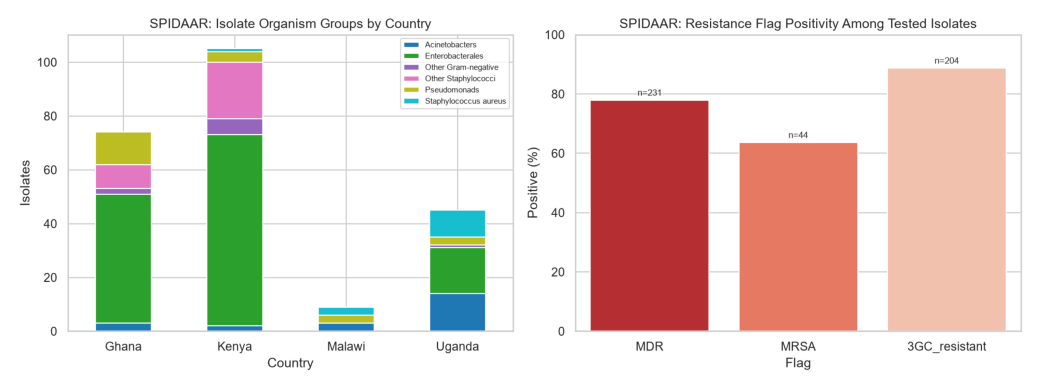

In [ ]:
with open(PROC / "spidaar_summary.json", encoding="utf-8") as f:
    spidaar = json.load(f)

iso = spidaar["isolates"]
print(f"SPIDAAR isolates n   : {iso['n']}")
print(f"Countries            : {iso['countries']}")
print("\nResistance flag positivity among *tested* isolates:")
for flag, v in iso["amr_flags"].items():
    print(f"  {flag:<15} {v['positive_pct']}%  (n tested = {v['n_tested']})")

show_figure("fig11_spidaar_isolate_groups.png")

Resistance flag positivity is strikingly high among *tested* isolates: **88.7% third-generation
cephalosporin resistance** (n=204 tested), **77.9% MDR** (n=231 tested), and **63.6% MRSA**
among tested *S. aureus* (n=44) — though these denominators are small and testing itself
appears selective (only isolates with clinical suspicion of resistance may have been
tested), so these are *not* representative population prevalence estimates. Enterobacterales
dominate the isolate mix in Ghana, Kenya, and Uganda; Malawi's small sample (n=10) limits
country-level inference.

### 6.2 Patient-level outcomes and healthcare-associated infections

In [ ]:
pat = spidaar["patients"]
print(f"SPIDAAR patients n     : {pat['n']}")
print(f"In-hospital mortality  : {pat['mortality_pct']}%")
print(f"Device use             : {pat['device_use_pct']}%  |  Surgery: {pat['surgery_pct']}%")
print(f"Length of stay (days)  : median {pat['los_days_median']}, mean {pat['los_days_mean']}")
print(f"Pathogen-positive      : {pat['pathogen_positive_pct']}%")

print("\nHAI category (confirmed), patient level:")
pd.Series(pat["hai_category"]).sort_values(ascending=False).to_frame("Patients")

SPIDAAR patients n     : 336
In-hospital mortality  : 16.37%
Device use             : 61.01%  |  Surgery: 39.58%
Length of stay (days)  : median 25.0, mean 30.91
Pathogen-positive      : 38.99%

HAI category (confirmed), patient level:


,Patients
BSI,107
cUTI,73
cSSTI,55
No HAI confirmed,53
HAP,40
cIAI,3
BSI + cUTI,2
BSI + cSSTI,1
BSI + cUTI + cIAI,1
HAP + cSSTI,1


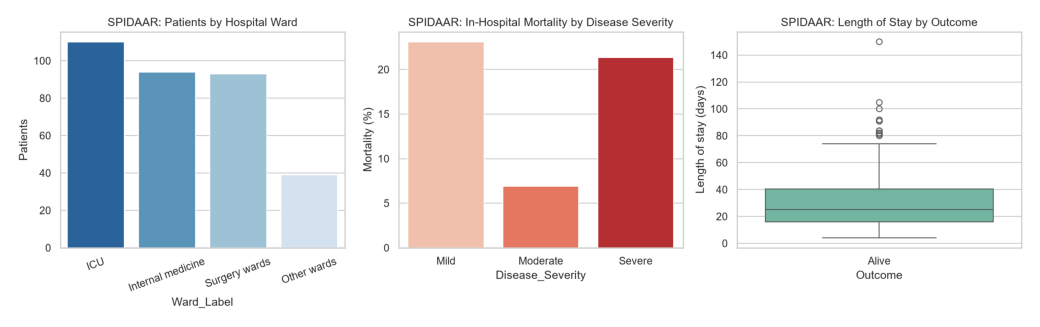

In [ ]:
show_figure("fig12_spidaar_patient_outcomes.png")

In-hospital mortality is **16.4%** overall and rises sharply with disease severity on
admission — from single digits for mild presentations to roughly **21% among patients
classified as severe** (see the middle panel above). BSI (bloodstream infection, 107
patients) and cUTI (73) are the most common confirmed HAI categories; 61.0% of patients
had an invasive device (catheter, ventilator, etc.) during hospitalisation, a well-known
HAI risk amplifier. One data nuance worth flagging: length-of-stay (`los`) is populated
only for patients discharged alive in this extract — deceased patients' time-in-hospital is
instead captured via the `dtpta` (days to death) field, which is why the boxplot above shows
only the "Alive" outcome group (see Limitations).

## 7. Cross-dataset synthesis

In [ ]:
synthesis = pd.DataFrame([
    {"Dataset": "ATLAS_Antibiotics", "n": f"{atlas['total_rows']:,}", "Geography": f"{atlas['n_countries']} countries",
     "Headline finding": "K. pneumoniae meropenem-R rose 4.2% (2007) -> 20.7% (2024); A. baumannii Africa penalty +7.4 pts vs global"},
    {"Dataset": "KEYSTONE", "n": f"{keystone['n']:,}", "Geography": f"{keystone['n_countries']} countries (0 in Africa)",
     "Headline finding": "Omadacycline retains potency vs. Gram-positives (MIC90 <= 0.25 ug/mL), flat 2015-2025"},
    {"Dataset": "Bedaquiline DREAM", "n": f"{dream['n']:,}", "Geography": f"{dream['n_countries']} countries",
     "Headline finding": "Median BDQ MIC 0.03 ug/mL; only 0.56% above provisional resistance threshold"},
    {"Dataset": "GASAR Study III", "n": f"{gasar['n']}", "Geography": "India",
     "Headline finding": "31.5% MBL/carbapenemase phenotype; VIM-1+NDM-1 co-carriage most frequent combination"},
    {"Dataset": "SPIDAAR RWE", "n": f"{iso['n']} isolates / {pat['n']} patients", "Geography": "Ghana, Kenya, Malawi, Uganda",
     "Headline finding": f"{pat['mortality_pct']}% in-hospital mortality; 88.7% 3GC-R among tested isolates"},
])
synthesis

,Dataset,n,Geography,Headline finding
0,ATLAS_Antibiotics,"1,011,168",83 countries,K. pneumoniae meropenem-R rose 4.2% (2007) -> ...
1,KEYSTONE,"96,302",20 countries (0 in Africa),Omadacycline retains potency vs. Gram-positive...
2,Bedaquiline DREAM,"5,928",11 countries,Median BDQ MIC 0.03 ug/mL; only 0.56% above pr...
3,GASAR Study III,496,India,31.5% MBL/carbapenemase phenotype; VIM-1+NDM-1...
4,SPIDAAR RWE,244 isolates / 336 patients,"Ghana, Kenya, Malawi, Uganda",16.37% in-hospital mortality; 88.7% 3GC-R amon...


Read together, the five datasets tell a coherent stewardship story:

1. **Carbapenem-sparing empiric therapy is increasingly justified** for *K. pneumoniae* and
   *A. baumannii* in the general ATLAS population, and *especially* in African settings
   where SPIDAAR shows 77.9% MDR positivity and GASAR shows 31.5% MBL/carbapenemase
   phenotypes — mechanism classes that carbapenems alone cannot address.
2. **Novel agents retain a window of efficacy.** Both omadacycline (KEYSTONE) and
   bedaquiline (DREAM) show stable, low MICs over their respective surveillance windows,
   supporting their continued use as later-line options — provided stewardship prevents the
   same overuse pattern that eroded older agents.
3. **Africa is systematically under-represented** in industry-sponsored global surveillance
   (2.9% of ATLAS, 0% of KEYSTONE) even though the region shows *higher* resistance burdens
   for the pathogens that are captured (e.g., *A. baumannii*). SPIDAAR and GASAR partially
   fill this gap but are small (n=244-496) relative to ATLAS's a million-isolate scale —
   reinforcing the case for expanded LMIC surveillance investment.
4. **Linked clinical outcomes change the interpretation of "resistance."** SPIDAAR is the
   only dataset here that connects isolate-level resistance to patient mortality (16.4%) and
   disease severity, and it shows mortality nearly doubling from moderate to severe
   presentations — a reminder that susceptibility percentages alone don't capture clinical
   stakes without linked outcome data.

## 8. Limitations

- **ATLAS Africa/LMIC coverage is sparse** (29,387 / 1,011,168 isolates; 12 of 83 countries),
  limiting statistical power for regional trend estimates outside South Africa and a handful
  of North/West African countries.
- **DREAM `SubType` field required substantial free-text normalization** (40+ raw spellings
  collapsed into 4 buckets); residual misclassification is possible for ambiguous entries
  (e.g., "?MDR", "*R").
- **KEYSTONE has zero African sites**, so omadacycline potency claims cannot be extrapolated
  to LMIC epidemiology without local surveillance.
- **GASAR and SPIDAAR are small, single-country/region convenience samples** (n=496 and
  n=244/336 respectively); they are valuable for mechanism and outcome detail but are not
  powered for precise prevalence estimation.
- **SPIDAAR testing appears non-random** — AMR flags (MDR, MRSA, 3GC-R) are only recorded
  for a subset of isolates, likely those with clinical suspicion of resistance, so positivity
  rates over-estimate true population prevalence.
- **SPIDAAR length-of-stay (`los`) is only populated for patients discharged alive**;
  mortality-linked duration should instead use the `dtpta` (days-to-death) field, which is
  not yet incorporated into the length-of-stay figure above.
- **The MDR proxy in ATLAS** (\u2265 2 resistant classes among 2-3 tracked antibiotics) is a
  simplification of formal MDR/XDR/PDR classification (Magiorakos et al. 2012) and should be
  treated as directional, not diagnostic.

## 9. References

- Vivli AMR Register: https://amr.vivli.org
- 2026 Vivli AMR Surveillance Data Challenge: https://amr.vivli.org/tag/datachallenge/
- Data Request 00013370 DOI: https://doi.org/10.25934/PR00013370
- Magiorakos, A.-P. et al. (2012). Multidrug-resistant, extensively drug-resistant and
  pandrug-resistant bacteria: an international expert proposal for interim standard
  definitions for acquired resistance. *Clinical Microbiology and Infection*, 18(3), 268-281.
- Methodological inspiration: Belindaharyini et al., *Vivli AMR Data Challenge 2025 (VIT)* —
  https://github.com/Belindaharyini/Vivli-AMR-data-challenge-2025-VIT-
- Full project narrative and figures: [`README.md`](../README.md)